# Segmentacja K-średnich zachowań abonentów za pomocą PROC FASTCLUS

## Podsumowanie wykonawcze

Ten notatnik dzieli syntetyczną bazę 100 abonentów sieci komórkowej na klastry behawioralne za pomocą `PROC FASTCLUS`, bazowej procedury SAS do klastrowania metodą k-średnich. Siedem cech użytkowania jest standaryzowanych do wartości z (z-score) za pomocą `PROC STDIZE`, tak aby zmienne o dużej skali (minuty rozmów, liczba SMS-ów) nie dominowały odległości euklidesowej, a następnie `PROC FASTCLUS` dopasowuje trzy klastry. Procedura raportuje odchylenie RMS wewnątrz klastra, ogólny współczynnik R-kwadrat i pseudo-F, które określają, jak dobrze segmentacja rozdziela bazę (tutaj ogólny R-kwadrat wynosi 0,575, a pseudo-F 65,75), oraz zapisuje przypisaną tabelę z etykietą `CLUSTER` dla każdego abonenta. Łączymy te etykiety z danymi w oryginalnej skali, profilujemy persony i przekazujemy przypisania do dalszej aktywacji.

## Źródła danych

| Zbiór danych | Opis | Wiersze | Kluczowe zmienne |
| ------- | ----------- | ---: | ------------- |
| `subscribers` | Syntetyczny miesięczny zrzut zachowań dla bazy abonentów operatora komórkowego, generowany bezpośrednio w kodzie za pomocą `call streaminit` / `rand()`. Trzy ukryte typy zachowań (duże zużycie danych, zorientowanie na głos, niskie zużycie) są mieszane z szumem. | 100 | `subscriber_id`, `tenure_months`, `monthly_data_gb`, `voice_minutes`, `sms_count`, `arpu`, `intl_minutes`, `support_calls`, `data_plan` (nominalna), `region` (nominalna) |

# Segmentacja K-średnich zachowań abonentów

**Branża:** Telekomunikacja &nbsp;|&nbsp; **Procedura:** `PROC FASTCLUS` (bazowe klastrowanie k-średnich SAS)

Operatorzy komórkowi obsługują abonentów, których miesięczne zachowania -- apetyt na dane, nawyki głosowe, wydatki i tarcie związane ze wsparciem -- mieszczą się w garści rozpoznawalnych wzorców. Odkrycie tych wzorców pozwala firmie dopasować działania retencyjne, sprzedawać właściwe pakiety i pozyskiwać podobnych klientów. Ten notatnik buduje segmentację behawioralną od początku do końca: generuje realistyczny zrzut abonentów, standaryzuje cechy, pozwala `PROC FASTCLUS` dopasować klastry, ocenia każdego abonenta i profiluje segmenty na przydatne persony. `PROC FASTCLUS` jest zaprojektowana dokładnie do tego rozłącznego zadania k-średnich i skaluje się do bardzo dużych baz, przechodząc przez dane zamiast budować pełną macierz odległości.

## 1. Generowanie syntetycznej bazy abonentów

Symulujemy 100 abonentów wylosowanych z trzech ukrytych archetypów zachowań -- **intensywnych użytkowników danych (streaming)**, **tradycjonalistów zorientowanych na głos** oraz klientów **lekkich/o niskim zużyciu** -- a następnie dodajemy szum, aby granice były rozmyte (tak jak w rzeczywistości). Każdy abonent posiada również dwa atrybuty kategoryczne, `data_plan` i `region`, których używamy później do *profilowania* segmentów. Ziarno losowości sprawia, że dane są odtwarzalne.

In [1]:
/* -----------------------------------------------------------
   Syntetyczny zrzut abonentow sieci komorkowej (100 wierszy).
   Trzy ukryte archetypy zachowan + szum, a takze dwa atrybuty
   kategoryczne do profilowania segmentow.
   ----------------------------------------------------------- */
DANE subscribers;
    CALL streaminit(20260531);

    DŁUGOŚĆ data_plan $16 region $16;

    POWTÓRZ subscriber_id = 100001 TO 100100;

        /* ukryty archetyp: 1=duze zuzycie danych, 2=glos, 3=niskie zuzycie */
        u = rand('uniform');
        JEŚLI      u < 0.38 WTEDY archetype = 1;
        PRZECIWNIE JEŚLI u < 0.70 WTEDY archetype = 2;
        PRZECIWNIE                  archetype = 3;

        tenure_months = MAX(1, round(rand('gamma', 2.2) * 12));

        JEŚLI archetype = 1 WTEDY POWTÓRZ;             /* intensywny uzytkownik danych */
            monthly_data_gb = MAX(0.5, rand('normal', 42, 11));
            voice_minutes   = MAX(0,   rand('normal', 180, 70));
            sms_count       = MAX(0,   round(rand('normal', 60, 30)));
            intl_minutes    = MAX(0,   rand('normal', 22, 14));
            arpu            = MAX(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        KONIEC;
        PRZECIWNIE JEŚLI archetype = 2 WTEDY POWTÓRZ;        /* zorientowany na glos */
            monthly_data_gb = MAX(0.2, rand('normal', 9, 4));
            voice_minutes   = MAX(0,   rand('normal', 620, 160));
            sms_count       = MAX(0,   round(rand('normal', 210, 80)));
            intl_minutes    = MAX(0,   rand('normal', 95, 45));
            arpu            = MAX(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        KONIEC;
        PRZECIWNIE POWTÓRZ;                              /* niskie zuzycie */
            monthly_data_gb = MAX(0.1, rand('normal', 3, 1.5));
            voice_minutes   = MAX(0,   rand('normal', 110, 50));
            sms_count       = MAX(0,   round(rand('normal', 35, 20)));
            intl_minutes    = MAX(0,   rand('normal', 6, 6));
            arpu            = MAX(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        KONIEC;

        /* przypisanie bezposrednie (bez tablicy) — unika obcinania
           wartosci nie-ASCII w tablicach znakowych o stalej szerokosci */
        JEŚLI      planpick = 1 WTEDY data_plan = 'Przedpłata';
        PRZECIWNIE JEŚLI planpick = 2 WTEDY data_plan = 'AbonamentM';
        PRZECIWNIE                       data_plan = 'Bezlimitowy';

        region_pick = rand('table', 0.30, 0.28, 0.22, 0.20);
        JEŚLI      region_pick = 1 WTEDY region = 'Północ';
        PRZECIWNIE JEŚLI region_pick = 2 WTEDY region = 'Południe';
        PRZECIWNIE JEŚLI region_pick = 3 WTEDY region = 'Wschód';
        PRZECIWNIE                          region = 'Zachód';

        /* zaokraglenie do zgrabnej precyzji raportowania */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        WYJŚCIE;
    KONIEC;

    ZACHOWAJ subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
WYKONAJ;


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Analiza rozkładów cech

Przed klastrowaniem przyjrzyjmy się skali i rozproszeniu każdej cechy behawioralnej. Skrajnie różne jednostki -- gigabajty, minuty, dolary, liczby -- są właśnie powodem, dla którego standaryzujemy zmienne interwałowe przed klastrowaniem; w przeciwnym razie zmienne o dużej skali, takie jak `voice_minutes`, zdominowałyby odległość euklidesową minimalizowaną przez `PROC FASTCLUS`.

                                                  The MEANS Procedure

 Variable         Label                           N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ------------------------------------------------------------------------------------------------------------------------------------------------
 tenure_months    Staż (mies.)                  100        27.6        18.9         3.0             13.0        22.0             37.5        98.0
 monthly_data_gb  Dane miesięczne (GB)          100        18.2        18.9         0.1              3.7         9.6             31.5        67.2
 voice_minutes    Minuty głosowe                100       304.2       236.6         0.0            125.0       217.0            527.5       912.0
 sms_count        Liczba SMS                    100       102.0       102.6         0.0             35.0        64.0            130.0       404.0
 intl_minutes     Minuty międzynarodowe         100  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


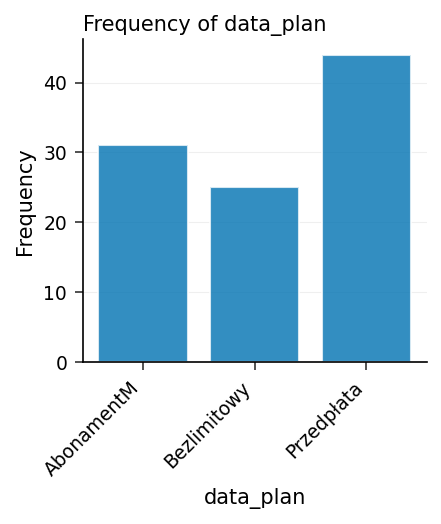

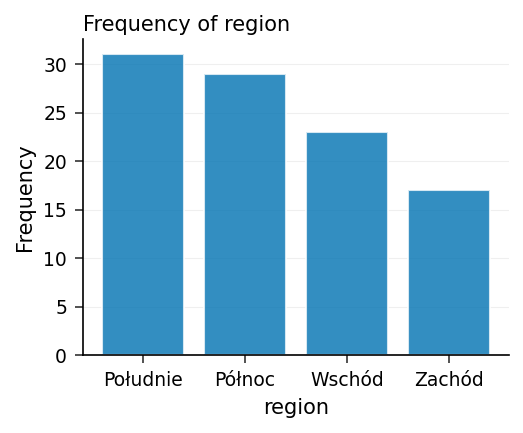

In [2]:
/* Statystyki podsumowujace dla zmiennych wejsciowych do klastrowania */
PROCEDURA ŚREDNIE DANE=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
    ZMIENNA tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    ETYKIETA tenure_months    = 'Staż (mies.)'
          monthly_data_gb  = 'Dane miesięczne (GB)'
          voice_minutes    = 'Minuty głosowe'
          sms_count        = 'Liczba SMS'
          intl_minutes     = 'Minuty międzynarodowe'
          arpu             = 'ARPU ($)'
          support_calls    = 'Zgłoszenia do wsparcia';
WYKONAJ;

/* Czestosc dwoch zmiennych kategorycznych */
PROCEDURA CZĘSTOŚCI DANE=subscribers;
    TABLES data_plan region / nocum;
    ETYKIETA data_plan = 'Plan taryfowy'
          region     = 'Region';
WYKONAJ;

## 3. Standaryzacja cech do wartości z

`PROC FASTCLUS` minimalizuje odległość euklidesową, więc zmienna mierzona w setkach minut przytłoczyłaby zmienną mierzoną w pojedynczych gigabajtach. `PROC STDIZE` z opcją `METHOD=STD` przeskalowuje każdą cechę interwałową do średniej 0 i odchylenia standardowego 1, nadając każdemu zachowaniu równą wagę w odległości. Kolumny kategoryczne i identyfikator przechodzą bez zmian, dzięki czemu możemy później profilować klastry w ich oryginalnej skali.

In [3]:
/* standaryzacja zmiennych interwalowych do wartosci z; identyfikatory
   i zmienne kategoryczne pozostaja bez zmian */
PROCEDURA stdize DANE=subscribers out=subs_std METHOD=std;
    ZMIENNA tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
WYKONAJ;


NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. Dopasowanie segmentacji k-średnich

Dopasowujemy trzy segmenty za pomocą `PROC FASTCLUS`. `MAXCLUSTERS=3` ustala *k*; `MAXITER=20` pozwala centrom klastrów iterować do zbieżności. Procedura raportuje **Podsumowanie klastrów** (liczebność i odchylenie RMS wewnątrz klastra dla każdego klastra), **Statystyki dla zmiennych** (współczynnik R-kwadrat wnoszony przez każdą cechę), **ogólny R-kwadrat** i **pseudo-F**, które mierzą, jak wyraźnie trzy klastry rozdzielają bazę, oraz **Średnie klastrów** w skali standaryzowanej. `OUT=scored` zapisuje wiersze wejściowe z powrotem z etykietą `CLUSTER` i wartością `DISTANCE` od każdego abonenta do centrum jego klastra.

In [4]:
/* dopasowanie k-srednich na standaryzowanych cechach: 3 segmenty */
PROCEDURA FASTCLUS DANE=subs_std maxclusters=3 MAXITER=20 out=scored;
    ZMIENNA tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    ETYKIETA tenure_months    = 'Staż (mies.)'
          monthly_data_gb  = 'Dane miesięczne (GB)'
          voice_minutes    = 'Minuty głosowe'
          sms_count        = 'Liczba SMS'
          intl_minutes     = 'Minuty międzynarodowe'
          arpu             = 'ARPU ($)'
          support_calls    = 'Zgłoszenia do wsparcia';
WYKONAJ;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. Dołączenie etykiet segmentów do danych w oryginalnej skali

Tabela wynikowa zawiera cechy standaryzowane; do profilowania chcemy opisać klastry w rzeczywistych gigabajtach, minutach i dolarach. Łączymy etykietę `CLUSTER` z powrotem z oryginalną tabelą `subscribers` po `subscriber_id`, a następnie zadajemy pierwsze pytanie, które zawsze zadaje marketing: *jak duży jest każdy segment?*

                                                   The FREQ Procedure

Segment    Frequency    Percent
--------------------------------
1                 36     36.00
2                 34     34.00
3                 30     30.00



NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


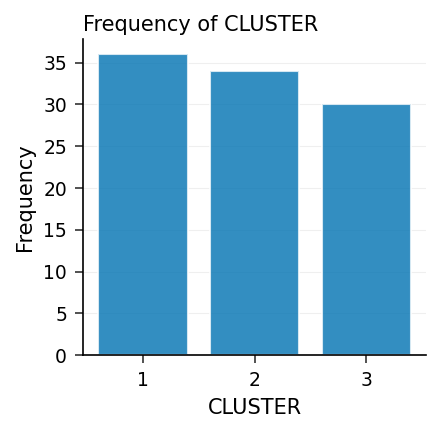

In [5]:
/* przeniesienie etykiety klastra z powrotem do danych w oryginalnej skali */
PROCEDURA SORTUJ DANE=scored(ZACHOWAJ=subscriber_id CLUSTER distance) out=clus_assign;
    WEDŁUG subscriber_id;
WYKONAJ;
PROCEDURA SORTUJ DANE=subscribers out=subs_sorted;
    WEDŁUG subscriber_id;
WYKONAJ;
DANE profile;
    POŁĄCZ subs_sorted clus_assign;
    WEDŁUG subscriber_id;
WYKONAJ;

/* Ilu abonentów trafiło do każdego segmentu? */
PROCEDURA CZĘSTOŚCI DANE=profile;
    TABLES CLUSTER / nocum;
    ETYKIETA CLUSTER = 'Segment';
WYKONAJ;

## 6. Profilowanie segmentów

Identyfikatory klastrów są bez znaczenia, dopóki nie opiszemy *zachowania* wewnątrz każdego z nich. Uśrednienie oryginalnych (niestandaryzowanych) cech według `CLUSTER` ujawnia personę stojącą za każdym segmentem -- kto korzysta ze streamingu, kto rozmawia, kto ledwo korzysta z sieci -- a mieszanka kategoryczna pokazuje, które plany i regiony koncentrują się w każdym segmencie.

                                                  The MEANS Procedure

                                    Analysis Variable : tenure_months Staż (mies.)

        Segment           N Obs           Mean
        --------------------------------------
        1                    36           28.9
        2                    34           25.8
        3                    30           28.1
        --------------------------------------

                               Analysis Variable : monthly_data_gb Dane miesięczne (GB)

        Segment           N Obs           Mean
        --------------------------------------
        1                    36            4.0
        2                    34           10.2
        3                    30           44.4
        --------------------------------------

                                   Analysis Variable : voice_minutes Minuty głosowe

        Segment           N Obs           Mean
        --------------------------------------
        1  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


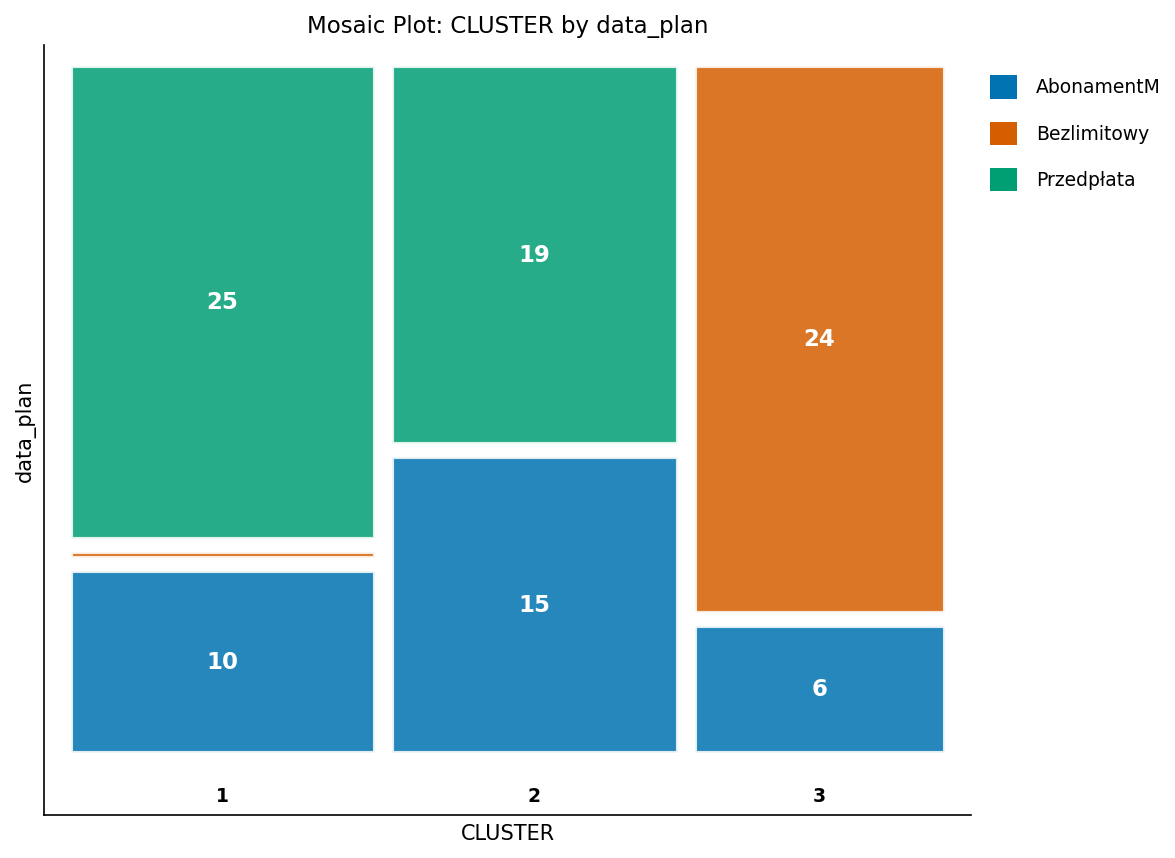

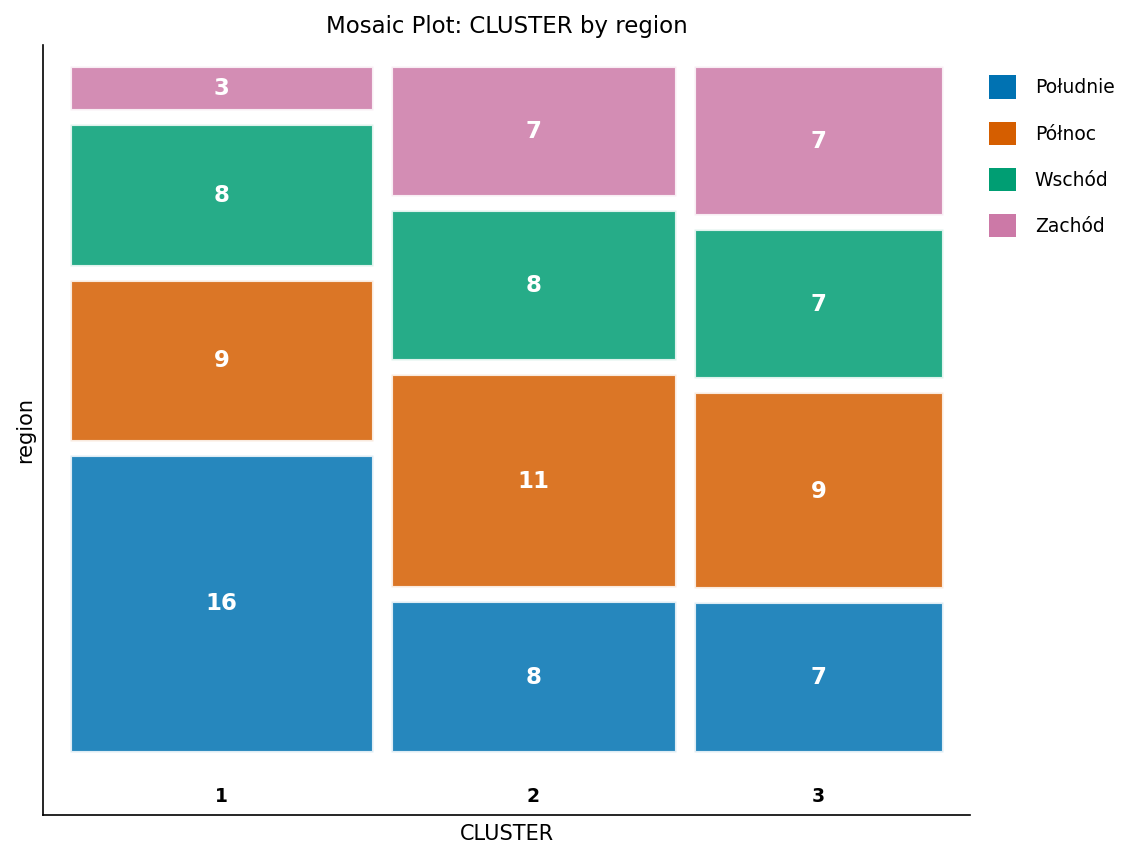

In [6]:
/* profil behawioralny: średnia każdej cechy wg segmentu */
PROCEDURA ŚREDNIE DANE=profile n mean maxdec=1;
    KLASA CLUSTER;
    ZMIENNA tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    ETYKIETA CLUSTER          = 'Segment'
          tenure_months    = 'Staż (mies.)'
          monthly_data_gb  = 'Dane miesięczne (GB)'
          voice_minutes    = 'Minuty głosowe'
          sms_count        = 'Liczba SMS'
          intl_minutes     = 'Minuty międzynarodowe'
          arpu             = 'ARPU ($)'
          support_calls    = 'Zgłoszenia do wsparcia';
WYKONAJ;

/* mieszanka kategoryczna w każdym segmencie */
PROCEDURA CZĘSTOŚCI DANE=profile;
    TABLES CLUSTER * data_plan / norow nopercent;
    TABLES CLUSTER * region    / norow nopercent;
    ETYKIETA CLUSTER   = 'Segment'
          data_plan  = 'Plan taryfowy'
          region     = 'Region';
WYKONAJ;

## 7. Wizualizacja segmentów

Obraz czyni segmentację namacalną. Zestawiamy apetyt na dane z użyciem głosu, kolorując według segmentu, i dodajemy wykres pudełkowy ARPU dla każdego segmentu, aby historia przychodów była widoczna na pierwszy rzut oka.


NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


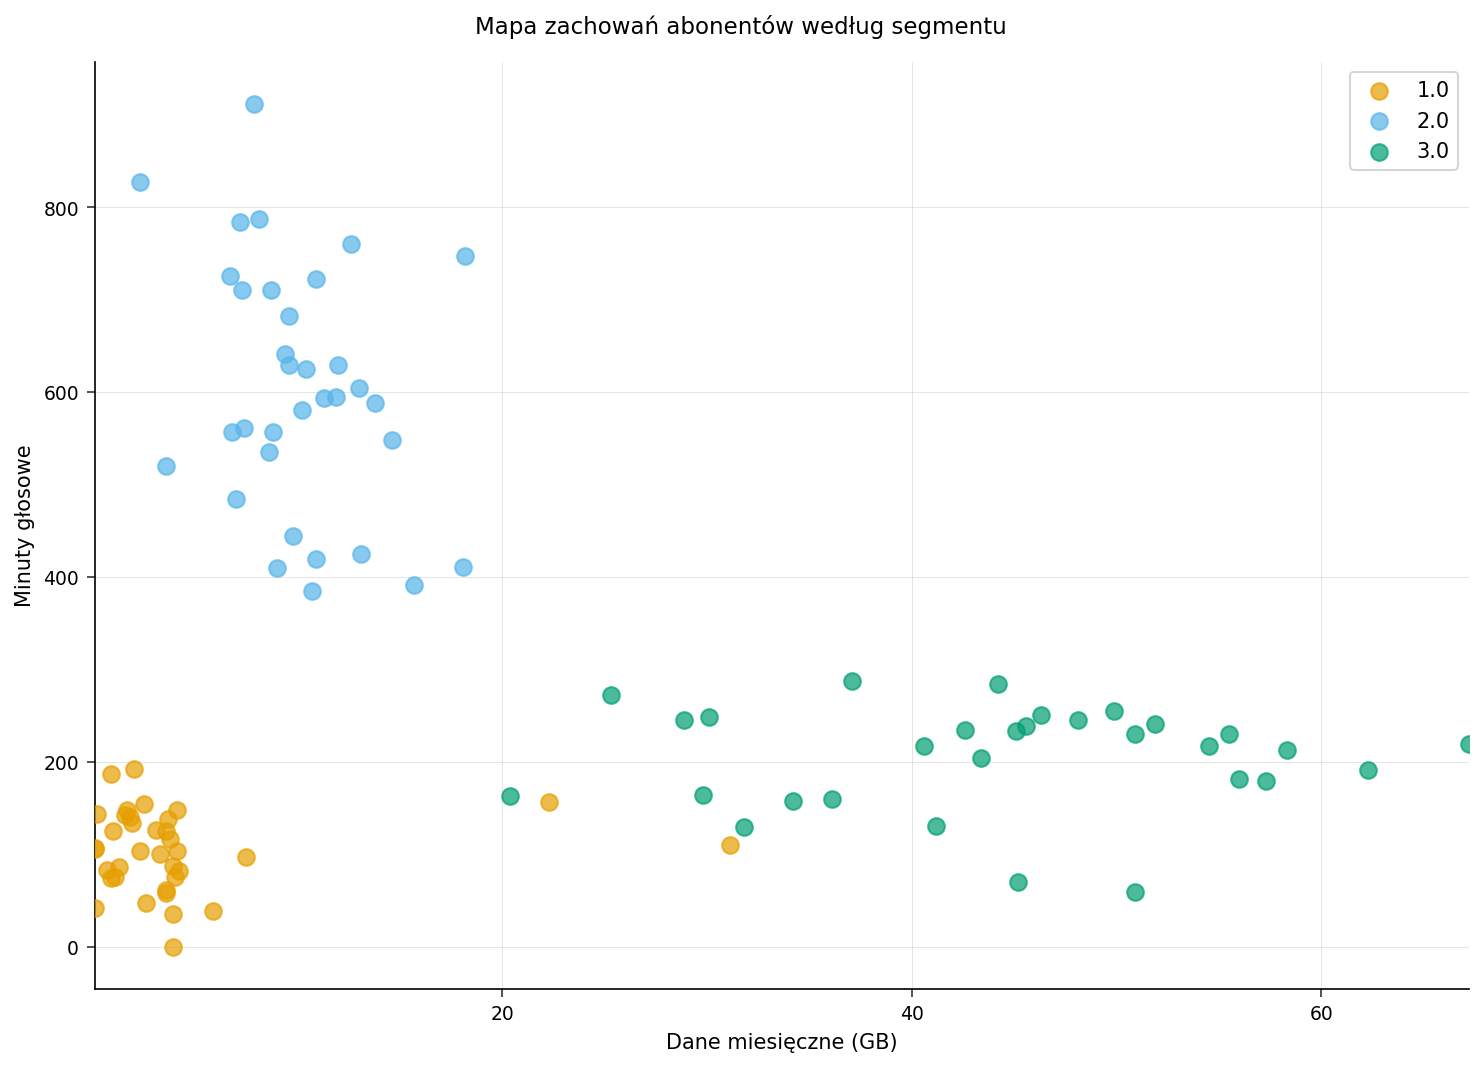

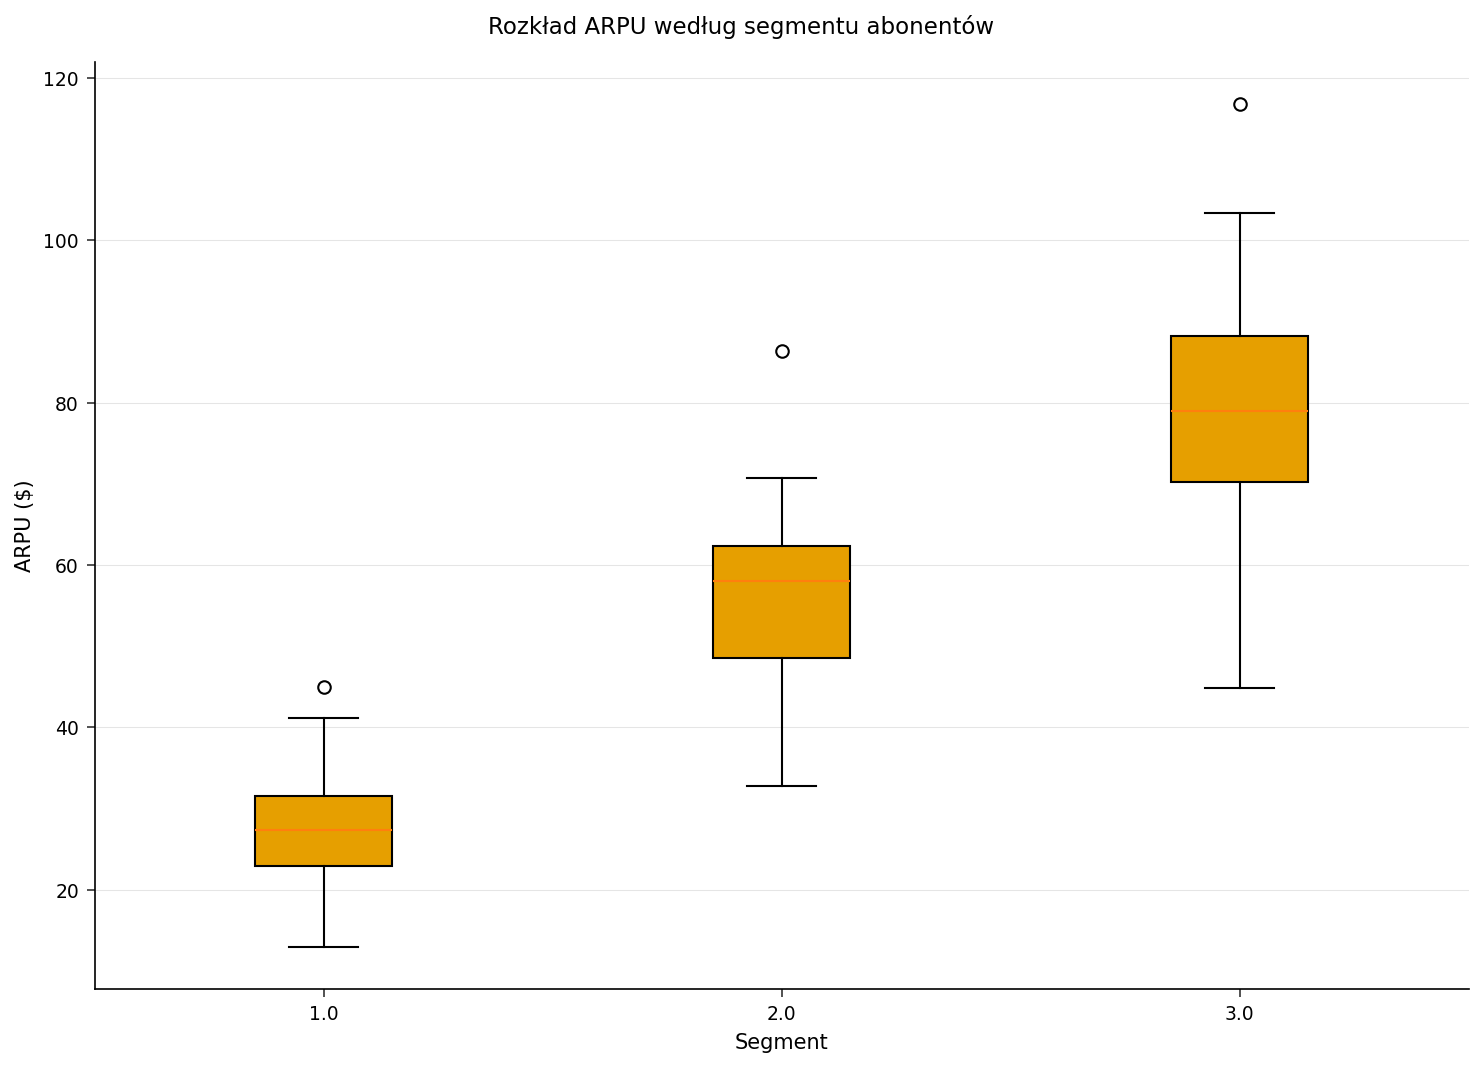

In [7]:
ODS GRAPHICS ON / imagefmt=svg WIDTH=720 HEIGHT=520;

/* mapa behawioralna: dane a głos, kolorowanie wg segmentu */
PROCEDURA SGPLOT DANE=profile;
    SCATTER x=monthly_data_gb y=voice_minutes
            / GROUP=CLUSTER
              MARKERATTRS=(size=8 SYMBOL=circlefilled)
              TRANSPARENCY=0.3;
    XAXIS ETYKIETA='Dane miesięczne (GB)' grid;
    YAXIS ETYKIETA='Minuty głosowe'     grid;
    TYTUŁ 'Mapa zachowań abonentów według segmentu';
WYKONAJ;

/* rozkład przychodów w każdym segmencie */
PROCEDURA SGPLOT DANE=profile;
    VBOX arpu / category=CLUSTER;
    XAXIS ETYKIETA='Segment';
    YAXIS ETYKIETA='ARPU ($)' grid;
    TYTUŁ 'Rozkład ARPU według segmentu abonentów';
WYKONAJ;

## 8. Eksport przypisanych segmentów

Na koniec przekazujemy przypisania do systemów CRM i kampanii marketingowych. Zachowujemy identyfikator, etykietę klastra i kluczowe pola behawioralne.

In [8]:
/* zapis przypisań segmentów do aktywacji */
DANE subscriber_segments;
    USTAW profile;
    ZACHOWAJ subscriber_id CLUSTER tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
WYKONAJ;

PROCEDURA DRUKUJ DANE=subscriber_segments(obs=10) noobs ETYKIETA;
    ETYKIETA subscriber_id   = 'ID abonenta'
          CLUSTER          = 'Segment'
          tenure_months    = 'Staż (mies.)'
          monthly_data_gb  = 'Dane miesięczne (GB)'
          voice_minutes    = 'Minuty głosowe'
          arpu             = 'ARPU ($)'
          data_plan        = 'Plan taryfowy'
          region           = 'Region';
    TYTUŁ 'Próbka ocenionych segmentów abonentów';
WYKONAJ;

                                         Próbka ocenionych segmentów abonentów                                          

ID abonenta  Segment   Staż (mies.)   Dane miesięczne (GB)   Minuty głosowe  ARPU ($)  Plan taryfowy     Region
     100001        1             30                    2.3              104        28  Przedpłata     Południe
     100002        2              8                   10.2              581     57.78  Przedpłata     Zachód
     100003        2              8                   10.7              385     55.66  AbonamentM     Północ
     100004        2             68                    7.4              561     70.68  Przedpłata     Północ
     100005        3             18                   45.6              239     63.85  Bezlimitowy    Północ
     100006        3             10                   30.1              249     88.33  Bezlimitowy    Wschód
     100007        1             62                    0.7               83     21.26  Przedpłata     Południe


NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Interpretacja wyników

`PROC FASTCLUS` odnalazła trzy czyste, dobrze rozdzielone segmenty. Dopasowanie jest solidne: **ogólny R-kwadrat wynosi 0,575**, a **pseudo-F wynosi 65,75**, co oznacza, że trzy klastry wyjaśniają około 58% całkowitej zmienności w standaryzowanych cechach. Rozdzielenie jest napędzane niemal wyłącznie przez sygnały behawioralne, na których nam zależy -- `voice_minutes` (R-kwadrat 0,858), `monthly_data_gb` (0,844) i `arpu` (0,771) niosą segmentację, podczas gdy `tenure_months` (0,000) i `support_calls` (0,193) wnoszą niemal nic, co potwierdza, że to *sposób*, w jaki abonent korzysta z sieci -- a nie to, jak długo jest klientem -- definiuje persony.

Trzy segmenty mapują się bezpośrednio na persony gotowe do wykorzystania w marketingu, profilowane tutaj w oryginalnej (niestandaryzowanej) skali:

| Segment | n (udział) | Charakterystyczne zachowanie | Mieszanka planów | Persona | Rekomendowane działanie |
| :-----: | :-------: | ------------------ | -------- | ------- | ---------------- |
| **3** | 30 (30%) | Najwyższe zużycie danych: **44,4 GB/mies.**, najwyższe wydatki **79,1 USD ARPU**, umiarkowany głos (205 min) | 24/30 **Bezlimitowy** | **Intensywni użytkownicy danych** | Ochrona i sprzedaż dodatkowa: szybsze pakiety, pakiety treści, aktualizacje urządzeń |
| **2** | 34 (34%) | Najwyższy głos **603 min/mies.**, **214 SMS**, **106 min międzynarodowych**, średnie wydatki **55,9 USD ARPU** | Przedpłata + AbonamentM, **brak Bezlimitowego** | **Tradycjonaliści zorientowani na głos** | Dodatki międzynarodowe, pakiety rodzinne/głosowe, nagrody lojalnościowe |
| **1** | 36 (36%) | Najniższe zużycie: **4,0 GB**, 104 min głosowych, najniższe wydatki **28,0 USD ARPU** | 25/36 **Przedpłata** | **Lekcy / o niskim zużyciu** | Dopasowanie planów, przypomnienia o autopłatnościach, tanie startery danych, by zwiększyć zużycie |

Mieszanka planów potwierdza odczyt behawioralny: segment intensywnych użytkowników danych jest w przeważającej mierze na planach **Bezlimitowych** (24 z 30), segment zorientowany na głos nie posiada **żadnych** abonentów Bezlimitowych, a segment o niskim zużyciu to głównie **Przedpłata** (25 z 36). Region natomiast rozkłada się równomiernie we wszystkich trzech segmentach -- geografia nie jest tutaj czynnikiem behawioralnym, co samo w sobie jest przydatnym wnioskiem dla targetowania kampanii.

**Dlaczego `PROC FASTCLUS` pasuje do tego problemu.** Wykonuje rozłączne k-średnie, przechodząc przez dane zamiast materializować pełną macierz odległości, więc ten sam program, który podzielił tych 100 abonentów, skaluje się do bardzo dużych baz. Standaryzacja za pomocą `PROC STDIZE` na początku usunęła obciążenie wynikające ze skali jednostek między gigabajtami, minutami i dolarami, dzięki czemu każde zachowanie wnosiło równy wkład do odległości euklidesowej; diagnostyka R-kwadrat wskazała następnie, *które* cechy faktycznie napędzały podział. Wynikowy zbiór -- etykieta `CLUSTER` dla każdego abonenta -- trafia bezpośrednio do pipeline'ów aktywacji, zamykając pętlę od surowego zachowania do targetowanej oferty.

---

<div style="font-size:11px;color:#9e9e9e">Ten notatnik jest udostępniany wyłącznie w celach demonstracyjnych. Dane są syntetyczne, a wnioski nie stanowią porady biznesowej.</div>